<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Paint_with_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paint with Data Part I

## The Standard Normal Curve

0.0
0.0
-3.0


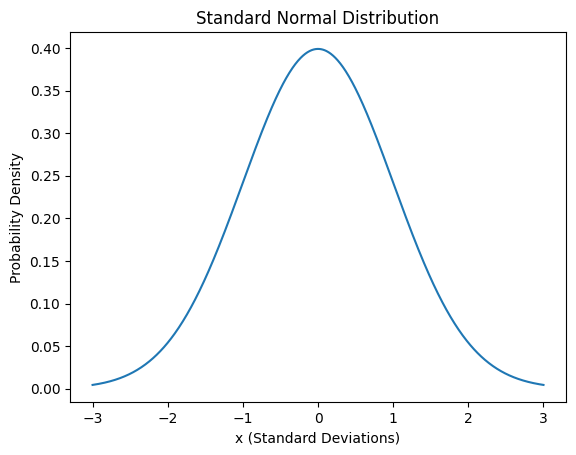

In [ ]:
# plot normal curve
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

mean = 0
lL, uL = mean - 3, mean + 3
x = np.linspace(lL, uL, 1000)
print(np.mean(x))
print(np.median(x))
print(stats.mode(x, keepdims=True)[0][0])
plt.plot(x, stats.norm.pdf(x, mean, 1))
plt.title("Standard Normal Distribution")
plt.xlabel("x (Standard Deviations)")
plt.ylabel("Probability Density")
plt.show()

## Translating the Standard Normal Curve

Probabilities: [0.0044318484119380075, 0.04016108044090312, 0.1745630742814002, 0.3639367217154837, 0.3639367217154836, 0.17456307428139997, 0.040161080440903094]
Step: 0.8571428571428571
Variance 1.3087135600000002
Standard Deviation 1.1439901922656506


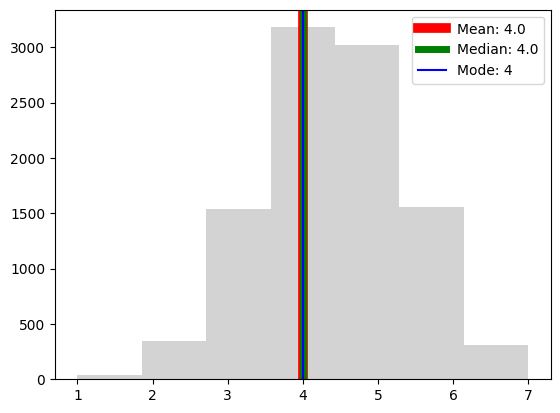

In [ ]:
# alternate to wing data
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import random

# my_list = np.arange(38, 52, 1)
my_list = np.arange(1, 8, 1)
x_axis = np.arange(-3, 3, 1)
size = 10000
probs = []
step = len(x_axis)/len(my_list)

for i in np.arange(-3, 3, step):
  # print(i, stats.norm.pdf(i, loc=0, scale=1))
  probs.append(stats.norm.pdf(i, loc=0, scale=1))

# print(len(my_list), len(x_axis), len(probs))
print('Probabilities:', probs)
print('Step:', step)
x = random.choices(my_list, weights=probs, k=size)

xmean = np.round(np.mean(x))
xmedian = np.median(x)
xmode = stats.mode(x, keepdims=True)[0][0]
print('Variance', np.var(x))
print('Standard Deviation', np.std(x))

plt.hist(x, bins=len(my_list), color='lightgray')
plt.axvline(x=xmean, color='red', label=f'Mean: {xmean}', linewidth=7)
plt.axvline(x=xmedian, color='green', label=f'Median: {xmedian}', linewidth=5)
plt.axvline(x=xmode, color='blue', label=f'Mode: {xmode}')
plt.legend()
plt.show()

## The Problem

Generate data that resembles the Advertising Dataset

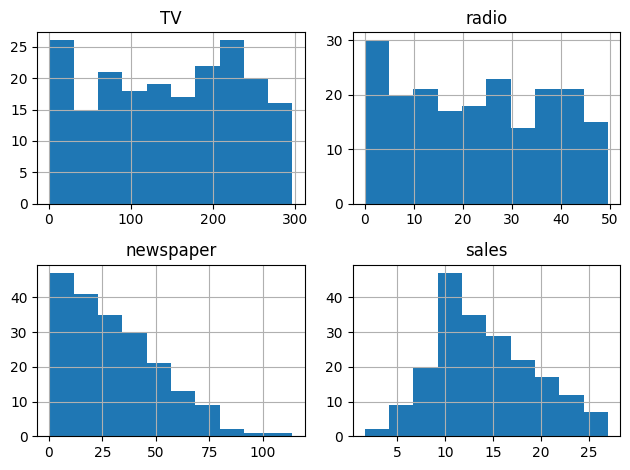

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ad = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/Advertising.csv')
ad.drop('Unnamed: 0', axis=1, inplace=True)
ad.hist()
plt.tight_layout()
plt.show()

## Univariate and Multivariate Distributions

### The Normal Distribution Formula
$f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi * \sigma^2}}e^{\frac{-(x-\mu)^2}{2\sigma^2}}$

### The Multivariate Normal Distribution Formula
$p(x; \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^k |\Sigma|}} e^{(-\frac{1}{2}(x-\mu)^T\Sigma^{-1} (x - \mu))}$



## Univariate Normal Distribution

* Parameters: $\mu, \sigma$
* mu: 0
* sigma: 1

$f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi \sigma^2}}e^{\frac{-(x-\mu)^2}{2\sigma^2}}$

In Python: 1/(np.sqrt(2 * np.pi * sigma\*\*2)) * np.exp( -(x-mu)\*\*2 / (2 * sigma**2))

<pre>
1/(np.sqrt(2 * np.pi * sigma**2)) * np.exp( -(x-mu)**2 / (2 * sigma**2))
</pre>

``1/(np.sqrt(2 * np.pi * sigma**2)) * np.exp( -(x-mu)**2 / (2 * sigma**2))``

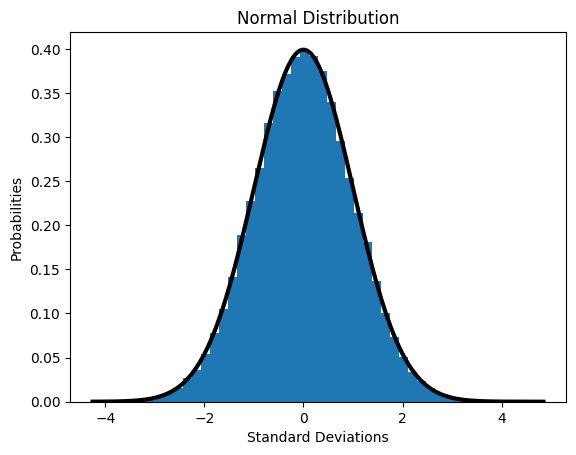

In [ ]:
# standard normal distribution with numpy
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
import numpy as np
import matplotlib.pyplot as plt

mu = 0
sigma = 1
x = np.random.normal(0, 1, 100000)
count, bins, ignored = plt.hist(x, density=True, bins=50)

# plot the distribution curve
x.sort()
plt.plot(x, 1/(np.sqrt(2 * np.pi * sigma**2)) * np.exp( -(x-mu)**2 / (2 * sigma**2)), linewidth=3, color='k')
plt.xlabel('Standard Deviations')
plt.ylabel('Probabilities')
plt.title('Normal Distribution')
plt.show()

## Multivariate Normal Distribution

* Parameters: $\mu, \Sigma$
* mu = [0, 0]
* Sigma = np.array([[.5, 1], [1, .5]])

$p(x; \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^k |\Sigma|}} e^{(-\frac{1}{2}(x-\mu)^T\Sigma^{-1} (x - \mu))}$

* https://en.wikipedia.org/wiki/Multivariate_normal_distribution
* https://sebastianraschka.com/Articles/2015_pca_in_3_steps.html#:~:text=The%20eigenvectors%20and%20eigenvalues%20of,the%20eigenvalues%20determine%20their%20magnitude
* https://www.researchgate.net/post/PCA_analysis_covariance-based_PCA_or_correlation-based_PCA#:~:text=It%20is%20well%20indicated%20that,when%20their%20scales%20are%20different

### Explanation

Google. (2024). Gemini (Sep 2 version) [Large language model]. https://gemini.google.com/

**Denominator: `√((2π)^k |Σ|)`**: This part of the formula acts as a normalizing constant, ensuring that the total probability density over all possible values integrates to 1, a fundamental requirement for any probability distribution.
* **`√((2π)^k)`**:
   * `2π`:  This term, representing 2 times pi (approximately 6.28), appears in the denominator of the standard normal distribution formula as well. It scales the distribution horizontally.
   * `k`:  This represents the number of dimensions or variables in your multivariate data.
   * `(2π)^k`: Raising 2π to the power of k accounts for the increased dimensionality of the data. In higher dimensions, there's more "space" for the distribution to spread out, so we need a larger normalizing constant to ensure the total probability remains 1.
   * `√((2π)^k)`: Taking the square root further adjusts the scaling to match the geometry of the multivariate normal distribution.
* **`|Σ|`**:
   * `Σ`:  This is the covariance matrix of your multivariate data. It captures the variances of the individual variables along its diagonal and the covariances (relationships) between the variables in its off-diagonal elements.
   * `|Σ|`: This denotes the determinant of the covariance matrix. The determinant provides a measure of the overall spread or volume occupied by the distribution in the multidimensional space. A larger determinant implies a wider spread, while a smaller determinant suggests a more concentrated distribution.
* **`√((2π)^k |Σ|)`**:
   * Combining these terms, the entire denominator scales the probability density function appropriately, ensuring that it integrates to 1 over the entire multidimensional space. It accounts for both the dimensionality of the data and the spread of the distribution as captured by the covariance matrix.

**In summary:**

The denominator ensures that the multivariate normal distribution is a valid probability distribution by adjusting the scale of the probability density function. It takes into account the number of dimensions (k) and the overall spread of the distribution as determined by the covariance matrix (Σ).

**Exponent**: e ^ ( -1/2 (x - μ)^T Σ^-1 (x - μ) ): This exponent plays a crucial role in shaping the characteristic bell curve of the multivariate normal distribution.
* **e**: The base of the natural logarithm. This is a constant approximately equal to 2.71828. It's used extensively in probability distributions and exponential growth/decay models.  
* **-1/2**: This negative fraction ensures that as the value inside the exponent increases, the overall value of the exponent decreases. This creates the downward sloping sides of the bell curve, indicating decreasing probability as we move away from the mean.
* **(x - μ)**: This represents the deviation of a data point x (a vector in the multivariate case) from the mean vector μ.
* **^T**: The superscript T denotes the transpose operation. It converts the column vector (x - μ) into a row vector.  
* **Σ^-1**: This is the inverse of the covariance matrix Σ. The covariance matrix captures how the different variables in your multivariate data are related to each other (their variances and covariances). Its inverse plays a crucial role in transforming the space in which the data exists.
* **(x - μ)**: This is the original deviation vector again. In essence, the exponent is calculating a scaled distance between the data point x and the mean μ.

**Here's a more intuitive explanation**:
* Deviation from the mean: (x - μ) calculates how far each component of the data point is from its corresponding mean.
* Accounting for covariance: Σ^-1 transforms these deviations, taking into account how the different variables are correlated. If two variables are highly correlated, a deviation in one will be associated with a deviation in the other. The inverse covariance matrix adjusts for these relationships.
* Squared distance: The transpose and multiplication operations essentially result in a squared distance (similar to the squared term in the univariate normal distribution). This ensures that deviations in any direction (positive or negative) contribute equally to the distance.
* Scaling: The -1/2 scales this squared distance, and e raised to this scaled distance determines the probability density at that point x. Points closer to the mean have a smaller scaled distance, leading to a higher exponent value and, consequently, a higher probability density.

**Key Takeaways**

The exponent reflects the Mahalanobis distance, a way to measure distance in multivariate space that accounts for correlations between variables.

The shape of the bell curve is determined by this exponent. A larger determinant of the covariance matrix |Σ| leads to a wider spread of the distribution, while a smaller determinant results in a narrower, more concentrated distribution.

<ipython-input-5-ad3704580bd6>:7: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x, y = np.random.multivariate_normal(mean, cov, 200).T


[[0.87447099 0.51505448]
 [0.51505448 1.15684075]]
[[1.         0.51208691]
 [0.51208691 1.        ]]


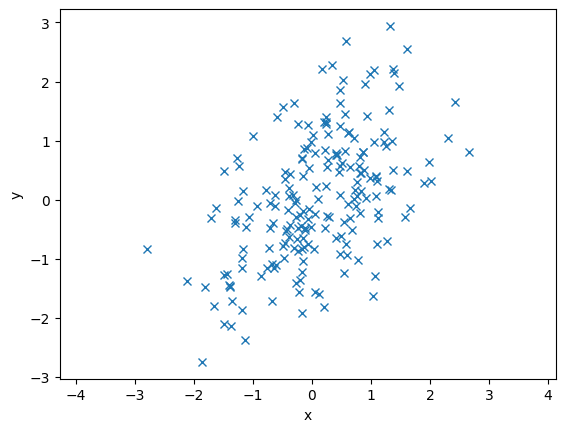

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mean = [0, 0]
cov = np.array([[.5, 1], [1, .5]]) # try [.5, 1], [1, .5]

x, y = np.random.multivariate_normal(mean, cov, 200).T
print(np.cov(x, y))
print(np.corrcoef(x, y))

plt.plot(x, y, 'x')
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Read Dataset

In [ ]:
import pandas as pd

ad = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/Advertising.csv')
ad.drop('Unnamed: 0', axis=1, inplace=True)
print(ad.shape)
print(ad.info())
ad.head()

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


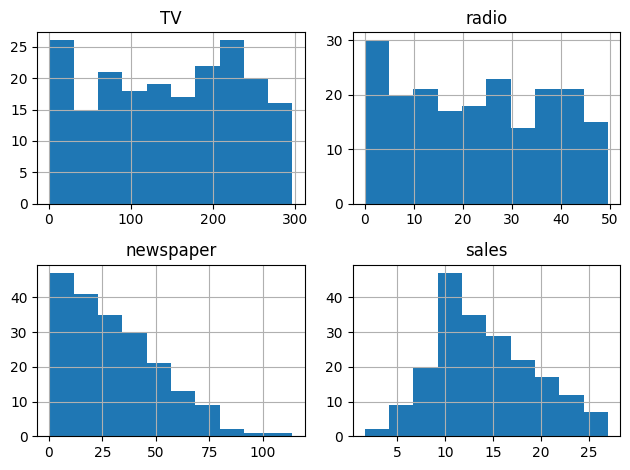

In [ ]:
# show histograms
import matplotlib.pyplot as plt

ad.hist()
plt.tight_layout()
plt.show()

## Make Regression

In [ ]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=3, n_informative=2, noise=10, random_state=42)
mr = pd.DataFrame(X, columns=['x1','x2','x3'])
mr['y'] = y
print(mr.shape)
print(mr.info())
mr.head()

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      200 non-null    float64
 1   x2      200 non-null    float64
 2   x3      200 non-null    float64
 3   y       200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


,x1,x2,x3,y
0,0.328751,-0.529760,0.513267,-15.429899
1,0.307300,0.812862,0.629629,76.244152
2,-0.269407,0.717542,1.502357,47.516152
3,0.821903,0.087047,-0.299007,23.871357
4,1.167782,0.254421,0.337603,53.486399


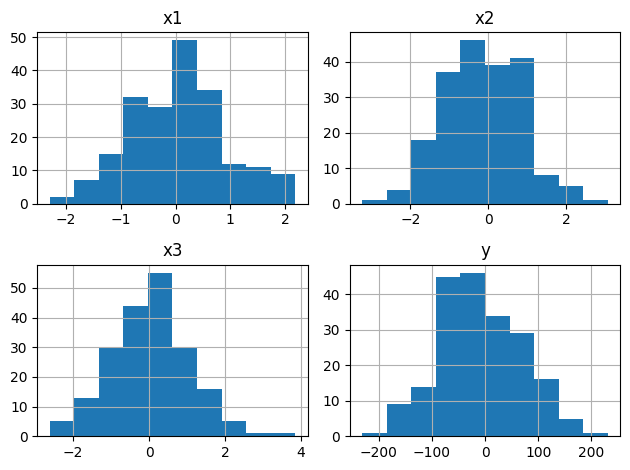

In [ ]:
# show histograms
import matplotlib.pyplot as plt

mr.hist()
plt.tight_layout()
plt.show()

## Create Distributions

<pre>
import numpy as np
import matplotlib.pyplot as plt
import random

print('Random value:', random.random())

pop = random.choices(range(1, 100), k=1000)
print(np.mean(pop))
print(np.var(pop))
print(np.std(pop))
plt.hist(pop)
plt.show()
</pre>

In [ ]:
# describe ad dataframe
ad.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


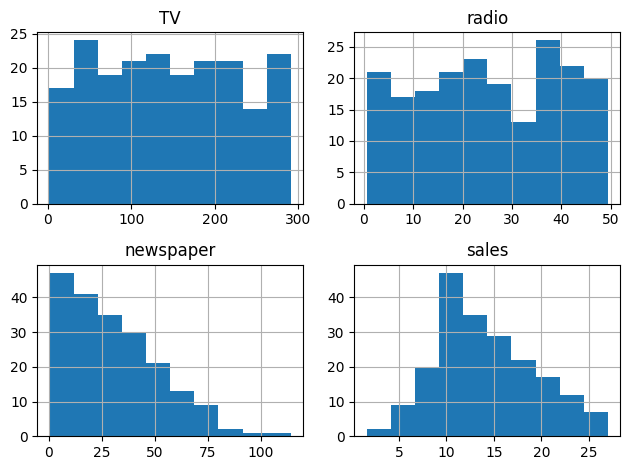

In [ ]:
# ctrl arrow to step through auto suggest
import numpy as np
import matplotlib.pyplot as plt
import random

def generate_uniform(n, min_val, max_val):
  return [random.uniform(min_val, max_val) for _ in range(n)]

TV = generate_uniform(200, ad['TV'].min(), ad['TV'].max())
radio = generate_uniform(200, ad['radio'].min(), ad['radio'].max())

my_df = pd.DataFrame({'TV': TV, 'radio': radio, 'newspaper': ad['newspaper'], 'sales': ad['sales']})
my_df.hist()
plt.tight_layout()
plt.show()


## Fitter

https://fitter.readthedocs.io/en/latest/

In [ ]:
pip install fitter

/usr/local/lib/python3.10/dist-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.004377,1087.567101,1100.760370,inf,0.034462,0.964897
exponpow,0.004476,1093.425225,1103.320177,inf,0.037294,0.933804
gamma,0.004602,1077.204091,1087.099043,inf,0.049977,0.680804
lognorm,0.004936,1085.119405,1095.014357,inf,0.063815,0.373592
rayleigh,0.005183,1133.307491,1139.904126,inf,0.085913,0.098436


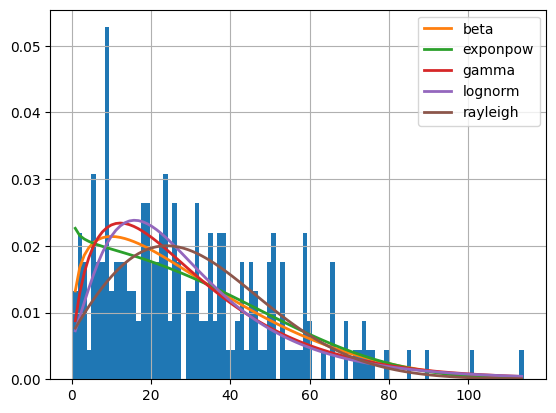

In [ ]:
# https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9
from fitter import Fitter, get_common_distributions

dists = get_common_distributions()
dists.append('beta')

f = Fitter(ad['newspaper'],
           distributions=dists
)
f.fit()
f.summary()

In [ ]:
f.fitted_param['exponpow']

(0.9554267967667686, 0.29999999999999993, 51.60881439116653)

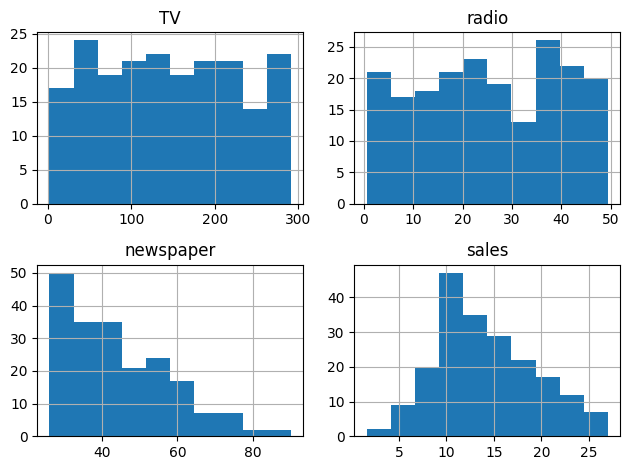

In [ ]:
# generate gamma
# ctrl arrow to step through auto suggest
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import expon, rayleigh, exponpow

# def generate_dist(n, min_val, max_val):
#   return [np.random.gamma(min_val, max_val) for _ in range(n)]

# newspaper = generate_dist(200, ad['newspaper'].min(), ad['newspaper'].max())
newspaper = exponpow.rvs(.95, loc=26, scale=31, size=200)

my_df['newspaper'] = newspaper
my_df.hist()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,0.091024,730.625077,740.520029,inf,0.061223,0.424710
chi2,0.091107,729.995701,739.890653,inf,0.061729,0.414430
gamma,0.091107,729.995581,739.890533,inf,0.061729,0.414428
norm,0.100191,716.446019,723.042654,inf,0.095383,0.049141
rayleigh,0.102128,692.106032,698.702666,inf,0.127467,0.002718


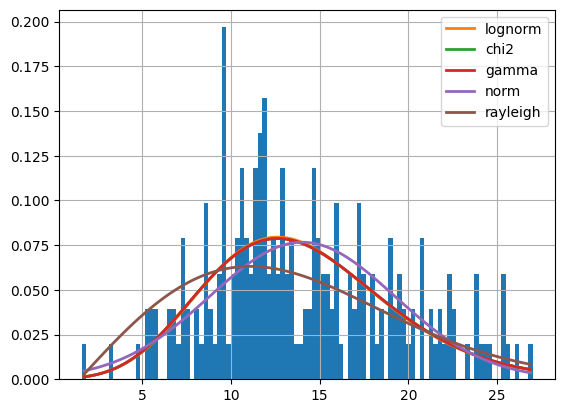

In [ ]:
from fitter import Fitter, get_common_distributions

dists = get_common_distributions()
dists.append('norm')

f = Fitter(ad['sales'],
           distributions=dists
)
f.fit()
f.summary()

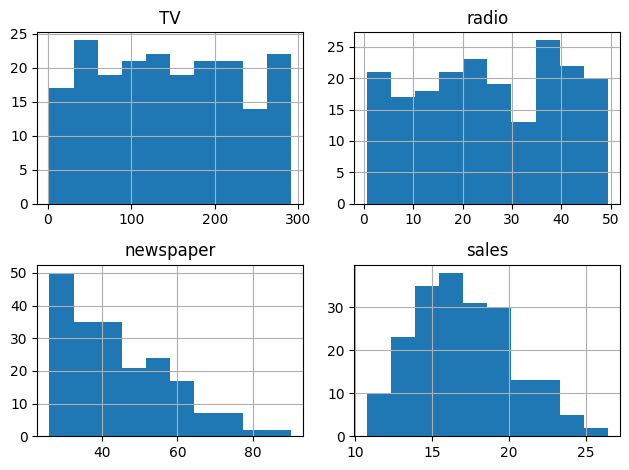

In [ ]:
# generate sales
from scipy.stats import skewnorm

sales = skewnorm.rvs(4, loc=13, scale=5, size=200)

my_df['sales'] = sales
my_df.hist()
plt.tight_layout()
plt.show()

## Shapes and Correlation

* https://datascience.stackexchange.com/questions/32373/is-pearson-coefficient-a-good-indicator-of-dependency-between-variables

In [ ]:
# correlation

my_df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.004284,-0.000565,-0.192100
radio,0.004284,1.000000,0.020265,-0.072901
newspaper,-0.000565,0.020265,1.000000,-0.033007
sales,-0.192100,-0.072901,-0.033007,1.000000


In [ ]:
# with ad.sales
my_df['sales'] = ad['sales']
my_df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.004284,-0.000565,0.036581
radio,0.004284,1.000000,0.020265,0.097518
newspaper,-0.000565,0.020265,1.000000,-0.039147
sales,0.036581,0.097518,-0.039147,1.000000


In [ ]:
# concentrate on correlation with TV
my_df['TV'] = ad['TV']
my_df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.024653,-0.047162,0.782224
radio,0.024653,1.000000,0.020265,0.097518
newspaper,-0.047162,0.020265,1.000000,-0.039147
sales,0.782224,0.097518,-0.039147,1.000000


## Triu vs Tril

* https://numpy.org/doc/stable/reference/generated/numpy.triu.html

[[ 7.37094989e+03  3.02025751e+01 -5.65164203e+01  3.50390195e+02]
 [ 0.00000000e+00  2.03613903e+02  4.03615457e+00  7.26016395e+00]
 [ 0.00000000e+00  0.00000000e+00  1.94822601e+02 -2.85085538e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.72218530e+01]]


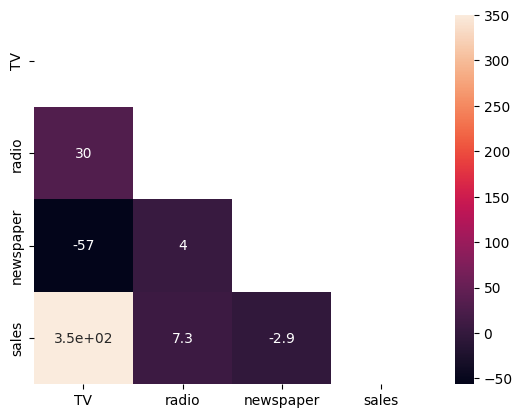

In [ ]:
# covariance with mask
# https://stackoverflow.com/questions/57414771/how-to-plot-only-the-lower-triangle-of-a-seaborn-heatmap
# https://numpy.org/doc/stable/reference/generated/numpy.triu.html
import seaborn as sns

my_cov = my_df.cov()
matrix = np.triu(my_cov)
print(matrix)
sns.heatmap(my_cov, mask=matrix, annot=True);

In [ ]:
# just TV and sales
my_df[['TV', 'sales']].cov().to_numpy()

array([[7370.94989322,  350.39019472],
       [ 350.39019472,   27.22185302]])

In [ ]:
# generate multivariate data
mean = [ad['TV'].mean(), ad['sales'].mean()]
Sigma = ad[['TV', 'sales']].cov().to_numpy()

x, y = np.random.multivariate_normal(mean, Sigma, 200).T
print(np.cov(x, y))
print(np.corrcoef(x, y))
print(len(x))

my_df['TV'] = x
my_df['sales'] = y
my_df[['TV', 'sales']].corr()

[[6224.54800164  294.41949311]
 [ 294.41949311   24.10113325]]
[[1.         0.76014058]
 [0.76014058 1.        ]]
200


,TV,sales
TV,1.000000,0.760141
sales,0.760141,1.000000


In [ ]:
# compare with original data
ad[['TV', 'sales']].corr()

,TV,sales
TV,1.000000,0.782224
sales,0.782224,1.000000


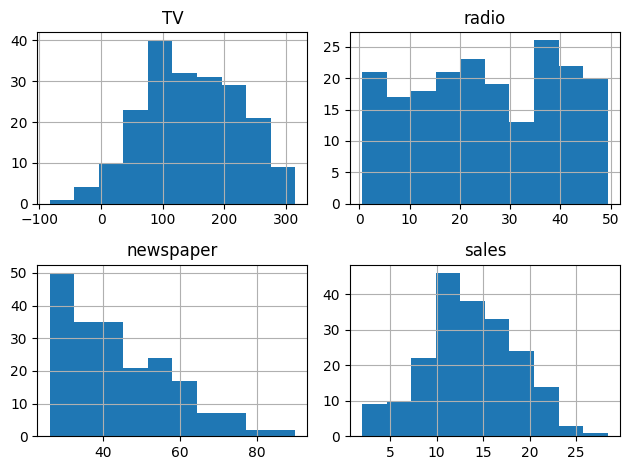

In [ ]:
import matplotlib.pyplot as plt

my_df.hist()
plt.tight_layout()
plt.show()

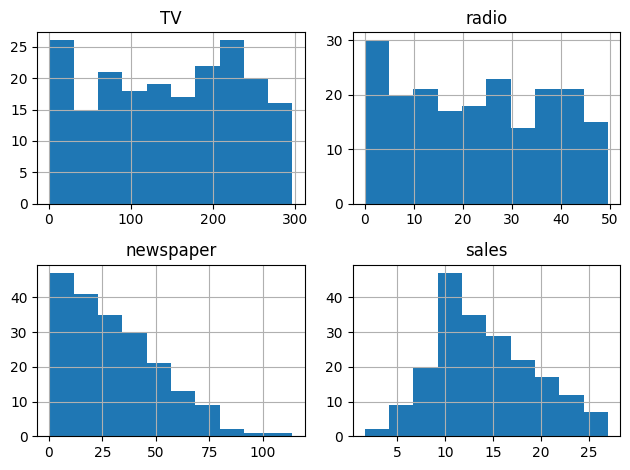

In [ ]:
ad.hist()
plt.tight_layout()
plt.show()

## Spurious Correlations

https://www.tylervigen.com/spurious-correlations

# Paint with Data Part II

                 TV     radio  newspaper     sales
TV         1.000000  0.004284  -0.000565 -0.192100
radio      0.004284  1.000000   0.020265 -0.072901
newspaper -0.000565  0.020265   1.000000 -0.033007
sales     -0.192100 -0.072901  -0.033007  1.000000


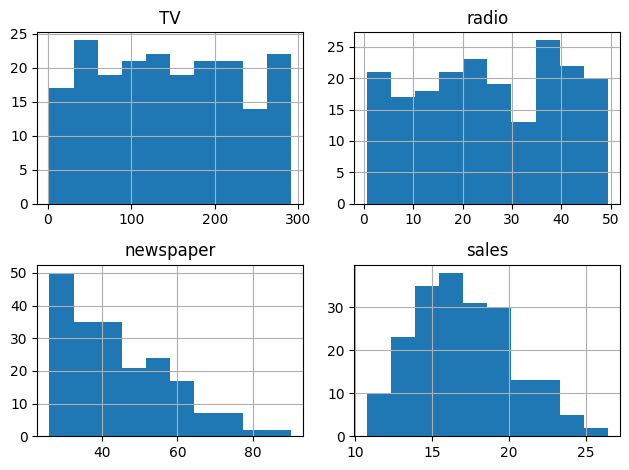

In [ ]:
# ctrl arrow to step through auto suggest
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import skewnorm, exponpow

# def generate_uniform(n, min_val, max_val):
#   return [random.uniform(min_val, max_val) for _ in range(n)]

# TV = generate_uniform(200, ad['TV'].min(), ad['TV'].max())
# radio = generate_uniform(200, ad['radio'].min(), ad['radio'].max())
# newspaper = exponpow.rvs(.95, loc=26, scale=31, size=200)
# sales = skewnorm.rvs(4, loc=13, scale=5, size=200)

my_df = pd.DataFrame({'TV': TV, 'radio': radio, 'newspaper': newspaper, 'sales': sales})
print(my_df.corr()) # use the print statement because only last line will be seen in output
my_df.hist()
plt.tight_layout()
plt.show()

In [ ]:
# print original correlation
ad.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


0.7822244248616061
                 TV     radio  newspaper     sales
TV         1.000000 -0.027513   0.007362  0.590924
radio     -0.027513  1.000000   0.020265 -0.072901
newspaper  0.007362  0.020265   1.000000 -0.033007
sales      0.590924 -0.072901  -0.033007  1.000000


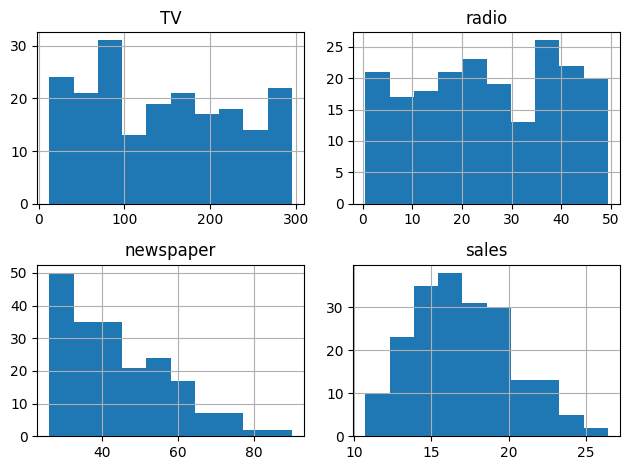

In [ ]:
import numpy as np
from scipy.stats import norm, uniform

target_corr = np.corrcoef(ad['TV'], ad['sales'])[0][1]
print(target_corr)
size = my_df.shape[0]  # number of rows in the dataframe

# map sales data to uniform data with specified correlation
z_scores = (my_df['sales'] - np.mean(my_df['sales'])) / np.std(my_df['sales'])
uniform_data = norm.cdf(target_corr * norm.ppf(np.random.uniform(size=size)) + np.sqrt(1 - target_corr**2) * z_scores)
my_df['TV'] = (uniform_data - np.mean(uniform_data)) * (my_df['TV'].std() / np.std(uniform_data)) + my_df['TV'].mean()

print(my_df.corr())
my_df.hist()
plt.tight_layout()
plt.show()

                  TV     radio  newspaper     sales  norm_sales    new_TV
TV          1.000000  0.054809   0.056648  0.782224   -0.008105 -0.078699
radio       0.054809  1.000000   0.354104  0.576223    0.071209  0.083659
newspaper   0.056648  0.354104   1.000000  0.228299    0.018082  0.073952
sales       0.782224  0.576223   0.228299  1.000000    0.034624 -0.039294
norm_sales -0.008105  0.071209   0.018082  0.034624    1.000000  0.664020
new_TV     -0.078699  0.083659   0.073952 -0.039294    0.664020  1.000000


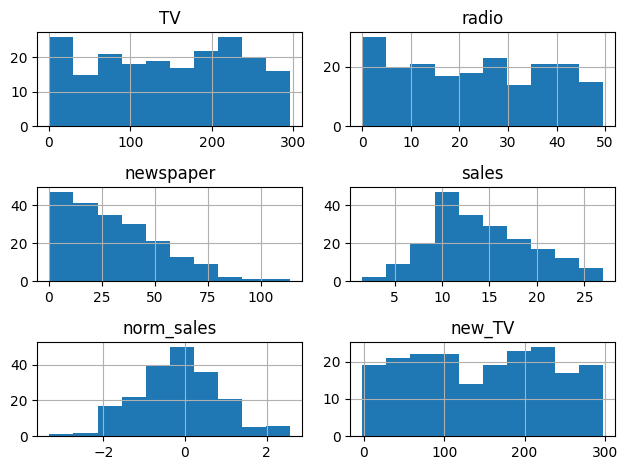

In [ ]:
# sales as normal standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform

ad = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/Advertising.csv')
ad.drop('Unnamed: 0', axis=1, inplace=True)

size = ad.shape[0]
normal_data = norm.ppf(np.random.uniform(size=size))
target_corr = np.corrcoef(ad['TV'], ad['sales'])[0][1]

ad['norm_sales'] = normal_data

# map sales data to uniform data with specified correlation
z_scores = (ad['norm_sales'] - np.mean(ad['norm_sales'])) / np.std(ad['norm_sales'])
uniform_data = norm.cdf(target_corr * norm.ppf(np.random.uniform(size=size)) + np.sqrt(1 - target_corr**2) * z_scores)
ad['new_TV'] = (uniform_data - np.mean(uniform_data)) * (ad['TV'].std() / np.std(uniform_data)) + ad['TV'].mean()

print(ad.corr())
ad.hist()
plt.tight_layout()
plt.show()

### Code Explanation

<pre>
z_scores = (my_df['sales'] - np.mean(my_df['sales'])) / np.std(my_df['sales'])
uniform_data = norm.cdf(target_corr * norm.ppf(np.random.uniform(size=size)) + np.sqrt(1 - target_corr**2) * z_scores)
my_df['TV'] = (uniform_data - np.mean(uniform_data)) * (my_df['TV'].std() / np.std(uniform_data)) + my_df['TV'].mean()
</pre>




Variance: $
\sigma^2 = \frac{1}{N}\sum({x}-\bar{x})^2
$

Covariance: $
cov(x, y) = \frac{1}{N} \sum_{i=1}^{N}(x_i - \bar{x}) (y_i - \bar{y})
$

Correlation: $
\rho_{x,y} = \frac{cov(x,y)}{\sigma_x\sigma_y} = \frac{\sum(x-\bar{x})(y-\bar{y})}{\sqrt{\sum(x-\bar{x})^2}\sqrt{\sum(y-\bar{y})^2}}
$

From AI (Gemini, Aug 28, 2024)

Let's derive the formula for the correlation between Z and X, where Z = aX + bY, and X and Y are independent standard normal random variables.

**Recall the following:**

* **Correlation Formula:** The correlation between two random variables U and V is given by:

```
Corr(U, V) = Cov(U, V) / (StdDev(U) * StdDev(V))
```

where:

* Cov(U, V) is the covariance between U and V
* StdDev(U) is the standard deviation of U
* StdDev(V) is the standard deviation of V

* **Properties of Covariance**

    * Cov(U, U) = Var(U) (Variance of U)
    * Cov(aU, bV) = ab * Cov(U, V)
    * where a and b are simple scaling factors or constants and can represent weights
    * Cov(U + V, W) = Cov(U, W) + Cov(V, W)
    * where W is another random variable
    * If U and V are independent, Cov(U, V) = 0

* **Properties of Variance**

    * Var(aU) = a^2 * Var(U)
    * Var(U + V) = Var(U) + Var(V) + 2Cov(U, V)
    * If U and V are independent, Var(U + V) = Var(U) + Var(V)
    * See Joint Random Variables

* **Standard Normal Distribution**

    * If X is a standard normal random variable, then:
        * E[X] (Expected value or mean of X) = 0
        * Var(X) = 1

**Derivation**

1. **Calculate Cov(Z, X)**

```
Cov(Z, X)
= Cov(aX + bY, X)
= Cov(aX, X) + Cov(bY, X)
= where a and b are simple scaling factors or constants and can represent weights
= a * Cov(X, X) + b * Cov(Y, X)
= a * Var(X) + 0 (Since X and Y are independent)
= a * 1
= a
```

2. **Calculate Var(Z)**

```
Var(Z)
= Var(aX + bY)
= Var(aX) + Var(bY) + 2Cov(aX, bY)
= a^2 * Var(X) + b^2 * Var(Y) + 2ab * Cov(X, Y)
= a^2 * 1 + b^2 * 1 + 0
= a^2 + b^2
```

3. **Calculate StdDev(Z)**

```
StdDev(Z) = sqrt(Var(Z)) = sqrt(a^2 + b^2)
```

4. **Put it all together**

```
Corr(Z, X)
= Cov(Z, X) / (StdDev(Z) * StdDev(X))
= a / (sqrt(a^2 + b^2) * 1)
= a / sqrt(a^2 + b^2)
```

**Therefore, we have derived the formula: Corr(Z, X) = a / sqrt(a^2 + b^2)**


**Core Idea: Linear Combination of Normal Variables**

The fundamental principle at play here is that a linear combination of two independent standard normal random variables results in another normal random variable. Moreover, we can control the correlation between this new normal variable and one of the original standard normal variables by adjusting the coefficients in the linear combination.

Mathematically:

* Let `X` and `Y` be two independent standard normal random variables (mean = 0, standard deviation = 1).
* Consider a new random variable `Z` defined as:
   ```
   Z = aX + bY
   ```
   where `a` and `b` are constants.

* `Z` will also be normally distributed.
* The correlation between `Z` and `X` is given by:
   ```
   Corr(Z, X) = a / sqrt(a^2 + b^2)
   ```
* Compared to $\rho_{x,y} = \frac{cov(x,y)}{\sigma_x\sigma_y} = \frac{\sum(x-\bar{x})(y-\bar{y})}{\sqrt{\sum(x-\bar{x})^2}\sqrt{\sum(y-\bar{y})^2}}$

**Code Interpretation**

Now, let's map this mathematical concept back to the code snippet.

1. `target_corr * norm.ppf(np.random.uniform(size=size))`

   * `np.random.uniform(size=size)` generates a uniformly distributed dataset.
   * `norm.ppf(...)` transforms these uniform values into standard normal quantiles (essentially, samples from a standard normal distribution `X`).
   * Multiplying by `target_corr` is equivalent to setting the coefficient `a` in the linear combination `Z = aX + bY`.
   * So, this part of the code represents the `aX` term.

2. `np.sqrt(1 - target_corr**2) * z_scores`

   * `z_scores` are the standardized `sales` data, which we can consider as samples from another standard normal distribution `Y`.
   * Multiplying by `np.sqrt(1 - target_corr**2)` is equivalent to setting the coefficient `b` in the linear combination.
   * This represents the `bY` term.

3. `The two scaled components are then added together`

   * This corresponds to the addition in the linear combination `Z = aX + bY`.
   * The resulting sum is a new normal random variable `Z` that has the desired correlation (`target_corr`) with the original `sales` data (`Y`).

**Final Transformation**

* The `norm.cdf(...)` at the beginning of the line applies the CDF of the standard normal distribution to `Z`.
* This transforms the normally distributed `Z` into a uniformly distributed variable between 0 and 1, which is stored in `uniform_data`.
* Crucially, this transformation preserves the correlation structure. So, the final `uniform_data` has the desired correlation with the original `sales` data.

**In essence:**

The code cleverly constructs a linear combination of two standard normal variables to achieve a specific correlation. Then, it applies a transformation to convert the resulting normal variable into a uniform one while maintaining the desired correlation.

Let's break down the use of `np.sqrt(1 - target_corr**2)` in the context of generating correlated uniform data.

**Purpose**

This expression serves to ensure that the coefficients `a` and `b` in the linear combination `Z = aX + bY` satisfy the following condition:

```
a^2 + b^2 = 1
```

This condition is crucial because it guarantees that the resulting variable `Z` will also have a standard deviation of 1 (i.e., it remains a standard normal variable).

**Explanation**

Recall that we want the correlation between `Z` and `X` to be equal to `target_corr`. We have:

```
Corr(Z, X) = a / sqrt(a^2 + b^2) = target_corr
```

If we enforce `a^2 + b^2 = 1`, the equation simplifies to:

```
a = target_corr
```

Now, we can solve for `b`:

```
a^2 + b^2 = 1
target_corr^2 + b^2 = 1
b^2 = 1 - target_corr^2
b = sqrt(1 - target_corr^2)
```

This is precisely why we multiply the `z_scores` (representing `Y`) by `np.sqrt(1 - target_corr**2)`. It ensures that the coefficient `b` is chosen correctly to achieve the desired correlation while maintaining the standard deviation of `Z` at 1.

**Target Correlation Squared and Subtracted from 1**

* `target_corr**2` represents the square of the desired correlation.
* `1 - target_corr**2` is the complement of the squared correlation.
* Taking the square root of this complement gives us the appropriate value for the coefficient `b`.

**In summary**

* `np.sqrt(1 - target_corr**2)` is used to calculate the correct coefficient `b` in the linear combination `Z = aX + bY`.
* This ensures that `Z` has the desired correlation with `X` while also maintaining a standard deviation of 1.
* The expression arises from the mathematical relationship between the coefficients `a` and `b` and the desired correlation.


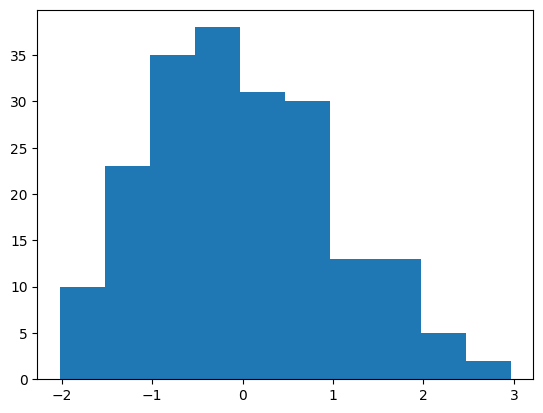

In [ ]:
plt.hist(z_scores)
plt.show()

# Paint with Data Part III

## Scipy Distributions

* https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions
* https://towardsdatascience.com/probability-distributions-with-pythons-scipy-3da89bf60565
* https://www.itl.nist.gov/div898/handbook/eda/section3/eda364.htm
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html

In [ ]:
from scipy.stats import (
    norm, beta, expon, gamma, genextreme, logistic, lognorm, triang, uniform, fatiguelife,
    gengamma, gennorm, dweibull, dgamma, gumbel_r, powernorm, rayleigh, weibull_max, weibull_min,
    laplace, alpha, genexpon, bradford, betaprime, burr, fisk, genpareto, hypsecant,
    halfnorm, halflogistic, invgauss, invgamma, levy, loglaplace, loggamma, maxwell,
    mielke, ncx2, ncf, nct, nakagami, pareto, lomax, powerlognorm, powerlaw, rice,
    semicircular, trapezoid, rice, invweibull, foldnorm, foldcauchy, cosine, exponpow,
    exponweib, wald, wrapcauchy, truncexpon, truncnorm, t, rdist
    )

distributions = [
    norm, beta, expon, gamma, genextreme, logistic, lognorm, triang, uniform, fatiguelife,
    gengamma, gennorm, dweibull, dgamma, gumbel_r, powernorm, rayleigh, weibull_max, weibull_min,
    laplace, alpha, genexpon, bradford, betaprime, burr, fisk, genpareto, hypsecant,
    halfnorm, halflogistic, invgauss, invgamma, levy, loglaplace, loggamma, maxwell,
    mielke, ncx2, ncf, nct, nakagami, pareto, lomax, powerlognorm, powerlaw, rice,
    semicircular, trapezoid, rice, invweibull, foldnorm, foldcauchy, cosine, exponpow,
    exponweib, wald, wrapcauchy, truncexpon, truncnorm, t, rdist
    ]

In [ ]:
dist_continu = [d for d in dir(stats) if
                isinstance(getattr(stats, d), stats.rv_continuous)]
dist_discrete = [d for d in dir(stats) if
                 isinstance(getattr(stats, d), stats.rv_discrete)]
print('number of continuous distributions: %d' % len(dist_continu))
print('number of discrete distributions:   %d' % len(dist_discrete))

number of continuous distributions: 107
number of discrete distributions:   19


## Use Cases

From AI (Gemini, Sept 10, 2024)


**Normal (Gaussian)**
* Heights and weights of a population
* Errors in measurements
* IQ scores
* Stock market returns (over short periods)
* Many natural phenomena

**Beta**
* Proportions or percentages (e.g., the proportion of defective items in a batch, the market share of a company)
* Probabilities of success in a series of trials
* Time to complete a task (when there's uncertainty in the duration)

**Exponential**
* Time between events in a Poisson process (e.g., time between customer arrivals at a store, time between radioactive decay events)
* Lifespans of certain electronic components
* Service times in a queue

**Gamma**
* Total waiting time until a certain number of events occur in a Poisson process
* Rainfall amounts over a specific period
* Time to complete a complex task with multiple stages

**Logistic**
* Growth of populations with limited resources
* Adoption of new technologies or products
* Probabilities of binary outcomes (e.g., success or failure) in certain situations

**Lognormal**
* Sizes of particles in aerosols or dust
* Incomes in a population
* Stock prices (over longer periods)
* Sizes of files on a computer

**Triangular**
* Situations where you have a minimum, maximum, and most likely value (e.g., project completion times, cost estimates)
* Subjective probability distributions when there's limited data

**Uniform**
* Random number generation
* Situations where all outcomes within a range are equally likely (e.g., lottery numbers, the position of a spinning wheel when it stops)

**Important Notes:**

* These are just examples; there are many other situations where these distributions can be applicable.
* In some cases, the fit of a particular distribution might be an approximation rather than a perfect match.
* The choice of distribution often depends on the specific context and available data.


# Paint with Data Part IV


## Faker

In [ ]:
# pip install Faker

In [ ]:
state_names=["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]

In [ ]:
# create demographic data
import numpy as np
import pandas as pd
from faker import Faker
fake = Faker()

output = []
for x in range(1000):
  binary = np.random.choice(['binary_1', 'binary_2'], p=[0.5, 0.5])
  output.append({
        'binary': binary, # sex assigned at birth
        'given_name': fake.first_name_female() if binary=='binary_1' else fake.first_name_male(),
        'surname': fake.last_name(),
        'date_of_birth': fake.date_of_birth(),
        'phone_number': fake.phone_number(),
        'email': fake.email(),
        'address': fake.address(),
        'city': fake.city(),
        'state': np.random.choice(state_names),
        'zipcode': fake.zipcode(),
        })

demographics = pd.DataFrame(output)
demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode
0,binary_2,Kevin,Landry,1989-05-28,279.391.8227,rachelgonzalez@example.net,Unit 0834 Box 9260\nDPO AA 17860,Rachelfurt,Connecticut,02465
1,binary_2,Spencer,Robertson,2016-11-24,001-576-734-9772x71766,sylvia13@example.com,"659 Fitzpatrick Keys Suite 024\nPort Cynthia, ...",South Elizabethshire,New York,37282
2,binary_1,Erica,Hurley,1936-10-29,+1-204-665-5879x9860,jeanne31@example.net,"31799 Stephen Flats\nFostershire, NJ 18510",Novakshire,Pennsylvania,15896
3,binary_1,Lauren,Tucker,2008-06-27,8528925338,hartmichael@example.net,Unit 9036 Box 6259\nDPO AA 05068,Davidburgh,Nebraska,57592
4,binary_1,Toni,Jenkins,1920-12-21,+1-679-393-3485x37854,thompsonlisa@example.com,"1094 Rowland Cove Apt. 700\nBrownmouth, DE 54543",East Nicholastown,Vermont,91034


In [ ]:
def parse_address_v2(text):
  """
  Parses an address string into street address, city, state, and zipcode.
  This version handles potential variations in the input format.

  Args:
    text: The address string to parse.

  Returns:
    A dictionary containing the parsed address components.
  """

  try:
    # Split the input into lines
    lines = text.strip().split('\n')

    # Extract the street address from the first line
    street_address = lines[0].strip()

    # Extract the city, state, and zipcode from the second line
    city_state_zip = lines[1].strip().split(',')
    city = city_state_zip[0].strip()
    state_zip = city_state_zip[1].strip().split()
    state = state_zip[0].strip()
    zipcode = state_zip[1].strip()

    return {
        'street_address': street_address,
        'city': city,
        'state': state,
        'zipcode': zipcode
    }

  except (IndexError, ValueError):
    return None

# Example usage
text = "80974 Jeffrey Mountains\nWest Benjamin, IL 82801"
address = parse_address_v2(text)

if address:
  print(address)
else:
  print("Could not parse the address.")

{'street_address': '80974 Jeffrey Mountains', 'city': 'West Benjamin', 'state': 'IL', 'zipcode': '82801'}


In [ ]:
# Apply the parse_address function to each row of the 'address' column
demographics[['nu_address', 'nu_city', 'nu_state', 'nu_zipcode']] = demographics['address'].apply(lambda x: pd.Series(parse_address_v2(x)))

demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,nu_address,nu_city,nu_state,nu_zipcode
0,binary_2,Kevin,Landry,1989-05-28,279.391.8227,rachelgonzalez@example.net,Unit 0834 Box 9260\nDPO AA 17860,Rachelfurt,Connecticut,02465,NaN,NaN,NaN,NaN
1,binary_2,Spencer,Robertson,2016-11-24,001-576-734-9772x71766,sylvia13@example.com,"659 Fitzpatrick Keys Suite 024\nPort Cynthia, ...",South Elizabethshire,New York,37282,659 Fitzpatrick Keys Suite 024,Port Cynthia,MP,74681
2,binary_1,Erica,Hurley,1936-10-29,+1-204-665-5879x9860,jeanne31@example.net,"31799 Stephen Flats\nFostershire, NJ 18510",Novakshire,Pennsylvania,15896,31799 Stephen Flats,Fostershire,NJ,18510
3,binary_1,Lauren,Tucker,2008-06-27,8528925338,hartmichael@example.net,Unit 9036 Box 6259\nDPO AA 05068,Davidburgh,Nebraska,57592,NaN,NaN,NaN,NaN
4,binary_1,Toni,Jenkins,1920-12-21,+1-679-393-3485x37854,thompsonlisa@example.com,"1094 Rowland Cove Apt. 700\nBrownmouth, DE 54543",East Nicholastown,Vermont,91034,1094 Rowland Cove Apt. 700,Brownmouth,DE,54543


In [ ]:
# drop address, city, state, zipcode and rename nu_ etc.
demographics.drop(['address', 'city', 'state', 'zipcode'], axis=1, inplace=True)
demographics.rename(columns={'nu_address': 'address', 'nu_city': 'city', 'nu_state': 'state', 'nu_zipcode': 'zipcode'}, inplace=True)
demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode
0,binary_2,Kevin,Landry,1989-05-28,279.391.8227,rachelgonzalez@example.net,NaN,NaN,NaN,NaN
1,binary_2,Spencer,Robertson,2016-11-24,001-576-734-9772x71766,sylvia13@example.com,659 Fitzpatrick Keys Suite 024,Port Cynthia,MP,74681
2,binary_1,Erica,Hurley,1936-10-29,+1-204-665-5879x9860,jeanne31@example.net,31799 Stephen Flats,Fostershire,NJ,18510
3,binary_1,Lauren,Tucker,2008-06-27,8528925338,hartmichael@example.net,NaN,NaN,NaN,NaN
4,binary_1,Toni,Jenkins,1920-12-21,+1-679-393-3485x37854,thompsonlisa@example.com,1094 Rowland Cove Apt. 700,Brownmouth,DE,54543


# Paint with Data Part V

### Create Independent Variable Correlated with Class

In [ ]:
import numpy as np
import pandas as pd

def generate_feature(df, class_col, coeff, intercept):
    """
    Generates normally distributed feature data for a logistic regression model.

    Args:
        df: The pandas DataFrame containing the class column.
        class_col: The name of the class column (containing 0s and 1s).
        coeff: The coefficient for the feature in the logistic regression model.
        intercept: The intercept of the logistic regression model.

    Returns:
        A pandas Series containing the generated feature data.
    """

    # Generate probabilities based on the class
    probs = np.random.rand(len(df))  # Initial random probabilities
    probs = np.where(df[class_col] == 1, probs * 0.8 + 0.2, probs * 0.8)  # Adjust for class

    # Apply the inverse logit (logit) function
    logits = np.log(probs / (1 - probs))

    # Calculate the feature values
    feature_values = (logits - intercept) / coeff

    return pd.Series(feature_values)



### Make Classification

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

def make_linear_y(row):
  model = LogisticRegression()
  model.fit(X, y)
  coefficients = model.coef_
  intercept = model.intercept_
  f_of_x = intercept + coefficients[0][0]*row['informative_1'] + coefficients[0][1]*row['informative_2']
  # print(f_of_x[0])
  return f_of_x[0]

# Adjust the make_classification parameters:
# Set n_informative and n_redundant to values that sum to less than n_features
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, random_state=42)
df = pd.DataFrame(X, columns=['informative_1', 'informative_2'])
df = pd.concat([demographics, df], axis=1).reset_index(drop=True)

df['target'] = df.apply(make_linear_y, axis=1) # an independent variable
df['class'] = y # the dependent variable
df['corr_feature_class'] = generate_feature(df, 'class', 0.5, -1)
df.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,informative_1,informative_2,target,class,corr_feature_class
0,binary_2,Kevin,Landry,1989-05-28,279.391.8227,rachelgonzalez@example.net,NaN,NaN,NaN,NaN,-0.999102,-0.663860,-0.904224,1,2.769979
1,binary_2,Spencer,Robertson,2016-11-24,001-576-734-9772x71766,sylvia13@example.com,659 Fitzpatrick Keys Suite 024,Port Cynthia,MP,74681,1.246686,1.153597,2.324370,1,2.782714
2,binary_1,Erica,Hurley,1936-10-29,+1-204-665-5879x9860,jeanne31@example.net,31799 Stephen Flats,Fostershire,NJ,18510,0.962777,0.859397,1.778217,1,2.609338
3,binary_1,Lauren,Tucker,2008-06-27,8528925338,hartmichael@example.net,NaN,NaN,NaN,NaN,-2.957441,2.033645,5.451235,1,4.873167
4,binary_1,Toni,Jenkins,1920-12-21,+1-679-393-3485x37854,thompsonlisa@example.com,1094 Rowland Cove Apt. 700,Brownmouth,DE,54543,1.141165,1.059449,2.153926,1,0.071820


### Automation Functions

1. gen_null(series, perc)
2. gen_quasi_constants(primary_label, variation_percentage=.2, replace=False)
3. gen_normal_data(mu=0, std=1, size=len(df))
4. gen_uniform_data(size=len(df))
5. gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df))
6. gen_correlated_normal_series(original_series, target_correlation, size=len(df))
7. gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df))
8. gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3)
9. gen_standard_scaling(mean=50, std_dev=10, size=len(df), scale_factor=1000)
10. gen_minmax_scaling(mean=50, std_dev=10, size=len(df), range_factor=10)
11. random_choice_data(choices, size)

In [ ]:
# functions
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


def gen_null(series, perc):
  """
  Introduces null values (np.nan) into a list based on a specified percentage.

  Args:
      var: The variable to modify.
      perc: The percentage of values to replace with nulls (0-100).

  Returns:
      The modified variable with null.
  """
  var = series.copy()
  num_nulls = int(len(var) * (perc / 100))
  indices_to_replace = np.random.choice(len(var), num_nulls, replace=False)

  for idx in indices_to_replace:
      var[idx] = np.nan

  return var

def gen_quasi_constants(primary_label, variation_percentage=.2, size=len(df)):
  """
  Generates quasi-constant labels for a Series, with a small percentage of variation.

  Args:
      primary_label: The main label to use for most values.
      variation_percentage: The percentage of labels to vary (0-100).

  Returns:
      A new Series containing the quasi-constant labels.
  """

  series = pd.Series(np.full(size, primary_label))
  num_variations = int(size * (variation_percentage / 100))
  variation_indices = np.random.choice(series.index, num_variations, replace=False)
  primary_label = primary_label + '_0'
  variation1 = primary_label + '_1'
  variation2 = primary_label + '_2'

  labels = pd.Series([primary_label] * len(series), index=series.index)
  labels.loc[variation_indices] = np.random.choice([variation1, variation2], size=num_variations)  # Adjust variations as needed

  return labels

def gen_normal_data(mu=0, std=1, size=len(df)):
  """
  Generates a normal dataset given the mean and standard deviation

  Args:
        mu: The mean of the normal distribution.
        std: The standard deviation of the normal distribution.
        size: The number of data points to generate.

  Returns:
        A normally distributed series.
  """
  return np.random.normal(mu, std, size)

def gen_uniform_data(size=len(df)):
  """
  Generates a uniform dataset

  Args:
        size: The number of data points to generate.

  Returns:
        A uniform distributed series.
  """
  return np.random.uniform(size=size)

def gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df)):
  """
  Generates two datasets with a multivariate normal distribution given the mean and covariance matrix

  Args:
        mean: The mean of each of the datasets.
        cov: The covariance matrix of the datasets.
        size: The number of data points to generate.

  Returns:
        Two correlated series.
  """
  ds1, ds2 = np.random.multivariate_normal(mean, cov, size, tol=1e-6).T # ds = dataset
  return ds1, ds2

def gen_correlated_normal_series(original_series, target_correlation, size=len(df)):
  """
  Generates a correlated series based on a given series.

  This function takes an original series as input and generates a new series
  that is correlated with the original series. The correlation between the
  original and generated series is approximately equal to the specified
  target correlation.

  The generated series is created by linearly transforming the original series
  and adding Gaussian noise with an adjusted standard deviation to achieve the
  desired correlation.

  Args:
      original_series (numpy.ndarray): The original series.
      target_correlation (float): The desired Pearson correlation coefficient
          between the original and generated series.

  Returns:
      numpy.ndarray: The generated correlated series.
  """
  return np.mean(original_series) + target_correlation * (original_series - np.mean(original_series)) \
  +  np.random.normal(0, np.sqrt(1 - target_correlation**2) * np.std(original_series), len(original_series))
  """
  Explanation

  This one-liner leverages the properties of linear transformations and normal distributions to generate a correlated series.

  It first centers the original_series by subtracting its mean.
  It then scales this centered series by the target_correlation.
  Finally, it adds Gaussian noise with a standard deviation adjusted to ensure the overall correlation matches the target_correlation.
  """

def gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df)):
  """
  Work in progress

  Generates a new series correlated with the given series based on the specified correlation coefficient,
  using rank correlation to ensure the generated series follows a uniform distribution.

  Args:
      original_series (numpy.ndarray or list): The original series.
      correlation_coefficient (float): The desired correlation coefficient between the original and generated series.
      size: The number of data points to generate.

  Returns:
      The generated correlated series with a uniform distribution.
  """
  z_scores = (original_series - np.mean(original_series)) / np.std(original_series)
  correlation_coefficient=.7
  return norm.cdf(correlation_coefficient * norm.ppf(np.random.uniform(size=size)) + np.sqrt(1 - correlation_coefficient**2) * z_scores)

def pearson_r_func(x, y, y_mean, y_std, desired_r):
    x_mean = np.mean(x)
    x_std = np.std(x)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = x_std * y_std * len(x)
    calculated_r = numerator / denominator
    return (calculated_r - desired_r)**2  # Minimize the squared difference

def minimize_r(original_series, target_correlation, size=len(df)):
    y = original_series
    y_mean = np.mean(y)
    y_std = np.std(y)
    desired_r = target_correlation

    # Initial guess for x values
    x0 = np.random.uniform(size=len(original_series))

    # Solve for x
    result = minimize(pearson_r_func, x0, args=(y, y_mean, y_std, desired_r))

    if result.success:
        x_solution = result.x
        # print("Solution for x:", x_solution)
        return x_solution
    else:
        print("Optimization failed.")

def gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3):
    """
    Generates a normal distribution with outliers.

    Args:
        mean (float): The mean of the normal distribution.
        std_dev (float): The standard deviation of the normal distribution.
        size (int): The number of samples to generate.
        outlier_percentage (float): The percentage of outliers to introduce (between 0 and 1).
        outlier_magnitude (float): The magnitude by which outliers deviate from the mean.

    Returns:
        numpy.ndarray: The generated data with outliers.
    """
    data = np.random.normal(mean, std_dev, size)
    num_outliers = int(size * outlier_percentage)
    outlier_indices = np.random.choice(size, num_outliers, replace=False)
    for index in outlier_indices:
        if np.random.rand() < 0.5:
            data[index] += outlier_magnitude
        else:
            data[index] -= outlier_magnitude

    return data

def gen_standard_scaling(mean=50, std_dev=10, size=len(df), scale_factor=1000):
  """
  Generates data with a specified mean and standard deviation, then scales it by a factor to create a distribution needing scaling.

  Args:
      mean (float): The mean of the original distribution.
      std_dev (float): The standard deviation of the original distribution.
      size (int): The number of samples to generate.
      scale_factor (float): The factor by which to scale the original distribution.

  Returns:
      numpy.ndarray: The generated data needing scaling.
  """
  original_data = np.random.normal(mean, std_dev, size)
  return original_data * scale_factor

def gen_minmax_scaling(mean=50, std_dev=10, size=len(df), range_factor=10):
  """
  Generates data with a specified mean and standard deviation, then scales and shifts it to create a distribution needing MinMax scaling.

  Args:
      mean (float): The mean of the original distribution.
      std_dev (float): The standard deviation of the original distribution.
      size (int): The number of samples to generate.
      range_factor (float): The factor to expand the range of the original distribution.

  Returns:
      numpy.ndarray: The generated data needing scaling.
  """

  # Generate the original data
  original_data = np.random.normal(mean, std_dev, size)

  # Expand the range of the data
  min_val = np.min(original_data)
  max_val = np.max(original_data)
  return (original_data - min_val) * range_factor + min_val

def random_choice_data(choices, size):
  """
  Generates a new series correlated with the given series based on the specified correlation coefficient,
  using rank correlation to ensure the generated series follows a uniform distribution.

  Args:
      original_series (numpy.ndarray or list): The original series.
      correlation_coefficient (float): The desired correlation coefficient between the original and generated series.

  Returns:
      numpy.ndarray: The generated correlated series with a uniform distribution.
  """
  return np.random.choice(choices, size=size)


In [ ]:
# categorical variables with little correlation to sales
df['random choice 2'] = random_choice_data(['Rand Choice 1', 'Rand Choice 2'], size=len(df))
df['random choice 4'] = random_choice_data(['North', 'South', 'East', 'West'], size=len(df))
df['random choice 7'] = random_choice_data(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], size=len(df))

# categorical random choices with random # of labels
num_labels = np.random.randint(3, 5)
df[f'random label num {num_labels}'] = random_choice_data([f'label num lo {i}' for i in range(1, num_labels + 1)], size=len(df))

num_labels = np.random.randint(10, 15)
df[f'random label num {num_labels}'] = random_choice_data([f'label num hi {i}' for i in range(1, num_labels + 1)], size=len(df))

In [ ]:
# categorical variables correlated with target
df['pd qcut1'] = pd.qcut(df['target'], 2, labels=['Low', 'High']) # bi label
df['pd qcut2'] = pd.qcut(df['target'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4']) # 4 labels

quantiles = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1]
df['pd qcut3'] = pd.qcut(df['target'], quantiles, labels=['G1', 'G2', 'G3', 'G4', 'G5', 'G6']) # 6 labels

In [ ]:
# generate four numerical normally distributed continuous features that have a correlation greater than absolute value of .5 with each other
# gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df))
df['multicollinearity 1'], df['multicollinearity 2'] = gen_multivariate_normal_data(mean=[0, 0], cov=[[1, .7], [.7, 1]], size=len(df))
df['multicollinearity 3'], df['multicollinearity 4'] = gen_multivariate_normal_data(mean=[0, 0], cov=[[1, .9], [.9, 1]], size=len(df))

In [ ]:
# generate two normally distributed features that are correlated with the target
# gen_correlated_normal_series(original_series, target_correlation, size=len(df))
df['correlated w target 1'] = gen_correlated_normal_series(df['target'], target_correlation=.5)
df['correlated w target 2'] = gen_correlated_normal_series(df['target'], target_correlation=.7)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 1000 non-null   object  
 1   given_name             1000 non-null   object  
 2   surname                1000 non-null   object  
 3   date_of_birth          1000 non-null   object  
 4   phone_number           1000 non-null   object  
 5   email                  1000 non-null   object  
 6   address                898 non-null    object  
 7   city                   898 non-null    object  
 8   state                  898 non-null    object  
 9   zipcode                898 non-null    object  
 10  informative_1          1000 non-null   float64 
 11  informative_2          1000 non-null   float64 
 12  target                 1000 non-null   float64 
 13  class                  1000 non-null   int64   
 14  corr_feature_class     1000 non-null   fl

                uniform corr 1  uniform corr 2    target
uniform corr 1        1.000000        0.472197  0.687678
uniform corr 2        0.472197        1.000000  0.682066
target                0.687678        0.682066  1.000000


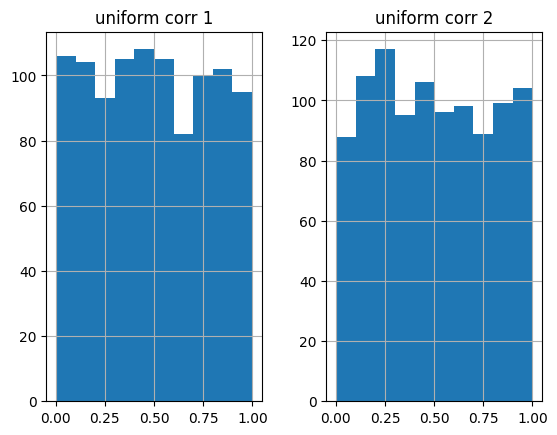

In [ ]:
# generate two uniformly distributed features that are correlated with the target
# gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df))
df['uniform corr 1'] = gen_correlated_uniform_series(df['target'])
df['uniform corr 2'] = gen_correlated_uniform_series(df['target'])

print(df[['uniform corr 1', 'uniform corr 2', 'target']].corr())
df[['uniform corr 1', 'uniform corr 2']].hist();

In [ ]:
# create two features that are duplicates of other features
df['duplicate_1'] = df['informative_1']
df['duplicate_2'] = df['informative_2']

In [ ]:
# create two numerical features with outliers
df['outliers 1'] = gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3)
df['outliers 2'] = gen_outliers(mean=3, std_dev=2, size=len(df), outlier_percentage=0.2, outlier_magnitude=2)

In [ ]:
# create a numerical feature that needs standard scaling
df['standard scaling'] = gen_standard_scaling()

In [ ]:
# create a numerical feature that needs min max scaling
df['min max scaling'] = gen_minmax_scaling()

In [ ]:
# generate null values
for col in df.drop(['class', 'informative_1', 'informative_2', 'target', 'duplicate_1', 'duplicate_2'], axis=1).columns:
    df[col] = gen_null(df[col], np.random.choice([0, 5, 10, 20, 30, 50], size=1).item())

In [ ]:
# create two features that have constant values
df['constant_1'] = 'constant_value'
df['constant_2'] = 'constant_value'

In [ ]:
# create two features with semi constant values
df['semi_constant_1'] = gen_quasi_constants('q_const', variation_percentage = 1)
df['semi_constant_2'] = gen_quasi_constants('q_const', variation_percentage = 1)

In [ ]:
print(df.info())  # check your work

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 1000 non-null   object  
 1   given_name             700 non-null    object  
 2   surname                700 non-null    object  
 3   date_of_birth          800 non-null    object  
 4   phone_number           500 non-null    object  
 5   email                  800 non-null    object  
 6   address                631 non-null    object  
 7   city                   623 non-null    object  
 8   state                  806 non-null    object  
 9   zipcode                626 non-null    object  
 10  informative_1          1000 non-null   float64 
 11  informative_2          1000 non-null   float64 
 12  target                 1000 non-null   float64 
 13  class                  1000 non-null   int64   
 14  corr_feature_class     700 non-null    fl